# LLM как автономная динамическая система: поиск аттракторов

**Цель:** смоделировать LLM как автономную динамическую систему и проверить, сходится ли её траектория в латентном пространстве к аттракторам.

## Гипотеза
При автономной генерации траектории {h_t} из разных начальных условий будут демонстрировать одну из трёх динамик:
1. Сходимость к неподвижной точке
2. Выход на циклический аттрактор
3. Хаотическое поведение

## Формализация
- Уравнение состояния: $h_{t+1} = F(C_t; θ)$
- Уравнение наблюдения: $x_{t+1} = argmax(G(h_{t+1}))$
- Уравнение контекста: $C_t = [x_{max(0, t-L+1)}, ..., x_t]$

Где $h_t ∈ R^{768}$ - латентное состояние (last token, last layer)

## Загрузка траекторий для всех промптов

In [3]:
import pickle

# Группа A: Семантически различные промпты
prompts_diverse = [
    "The gravitational constant G is approximately",
    "In a binary tree data structure, each node has",
    "The French Revolution began in the year",
    "To bake a simple sponge cake, first preheat the oven to",
    "Quantum entanglement is a phenomenon where"
]

# Группа B: Близкие вариации
prompts_similar = [
    "The cat sat on the mat",
    "A cat sat on the mat",
    "The cat sat on a mat",
    "A cat sits on the mat",
    "The dog sat on the mat",
    "The cat lay on the mat",
    "On the mat sat the cat"
]

# Группа C: Нейтральные промпты
prompts_neutral = [
    "The",
    ".",
    "Therefore,"
]

all_prompts = {
    'diverse': prompts_diverse,
    'similar': prompts_similar,
    'neutral': prompts_neutral
}

with open('experiment_results.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

trajectories = loaded_data['trajectories']
generated_texts = loaded_data['generated_texts']

print("Результаты успешно загружены из 'experiment_results.pkl'")

Результаты успешно загружены из 'experiment_results.pkl'


## Анализ аттракторов: функции для вычисления метрик

In [39]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
from typing import List, Dict, Tuple

def analyze_fixed_point(trajectory: np.ndarray, window_size: int = 100, threshold: float = 0.001) -> Dict:
    """
    Анализирует сходимость к неподвижной точке.
    """
    # Берем последние window_size шагов
    tail = trajectory[-window_size:]
    
    # Вычисляем косинусные расстояния между соседними состояниями
    distances = []
    for i in range(len(tail) - 1):
        dist = cosine_distances([tail[i]], [tail[i+1]])[0, 0]
        distances.append(dist)
    
    mean_distance = np.mean(distances)
    is_fixed_point = mean_distance < threshold
    
    return {
        'is_fixed_point': is_fixed_point,
        'mean_distance': mean_distance,
        'distances': distances
    }

def analyze_cycle(trajectory: np.ndarray, window_size: int = 100, 
                 max_period: int = 50, threshold: float = 0.05) -> Dict:
    """
    Анализирует наличие циклического аттрактора.
    """
    tail = trajectory[-window_size:]
    
    best_period = None
    best_distance = float('inf')
    
    for period in range(1, min(max_period + 1, len(tail) // 2)):
        distances = []
        
        # Проверяем, повторяется ли паттерн с данным периодом
        for i in range(period, len(tail)):
            dist = cosine_distances([tail[i]], [tail[i - period]])[0, 0]
            distances.append(dist)
        
        if distances:
            mean_dist = np.mean(distances)
            if mean_dist < best_distance:
                best_distance = mean_dist
                best_period = period
    
    is_cycle = best_distance < threshold if best_period else False
    
    return {
        'is_cycle': is_cycle,
        'best_period': best_period,
        'best_distance': best_distance
    }

def analyze_chaos(trajectory1: np.ndarray, trajectory2: np.ndarray, 
                 threshold: float = 0.005) -> Dict:
    """
    Анализирует хаотическое поведение через расхождение близких траекторий.
    """
    min_length = min(len(trajectory1), len(trajectory2))
    
    # Вычисляем расстояния между траекториями на каждом шаге
    distances = []
    for i in range(min_length):
        dist = np.linalg.norm(trajectory1[i] - trajectory2[i])
        distances.append(dist)
    
    # Логарифм расстояний для поиска экспоненциального роста
    log_distances = np.log(np.array(distances) + 1e-10)  # Избегаем log(0)
    
    # Линейная регрессия для оценки показателя Ляпунова
    time_steps = np.arange(len(log_distances))
    lyapunov_exponent = np.polyfit(time_steps, log_distances, 1)[0]
    
    is_chaotic = lyapunov_exponent > threshold
    
    return {
        'is_chaotic': is_chaotic,
        'lyapunov_exponent': lyapunov_exponent,
        'distances': distances
    }

print("Функции анализа аттракторов определены")

Функции анализа аттракторов определены


## Проведение анализа аттракторов

In [44]:
# Анализ каждой траектории
analysis_results = {}

print("Анализ аттракторов...")

for group_name, group_trajectories in trajectories.items():
    analysis_results[group_name] = []
    
    print(f"\nГруппа: {group_name}")
    
    for i, trajectory in enumerate(group_trajectories):
        prompt = all_prompts[group_name][i]
        
        # Анализ неподвижной точки
        fixed_point_analysis = analyze_fixed_point(trajectory)
        
        # Анализ цикла
        cycle_analysis = analyze_cycle(trajectory)
        
        result = {
            'prompt': prompt,
            'group': group_name,
            'trajectory_index': i,
            'fixed_point': fixed_point_analysis,
            'cycle': cycle_analysis
        }
        
        analysis_results[group_name].append(result)
        
        # Вывод результатов
        print(f"  Промпт {i+1}: '{prompt[:40]}...'")
        print(f"    Неподвижная точка: {fixed_point_analysis['is_fixed_point']} "
              f"(расстояние: {fixed_point_analysis['mean_distance']:.6f})")
        print(f"    Цикл: {cycle_analysis['is_cycle']} "
              f"(период: {cycle_analysis['best_period']}, "
              f"расстояние: {cycle_analysis['best_distance']:.6f})")

# Анализ хаоса для группы похожих промптов
print("\nАнализ хаотического поведения (группа 'similar'):")
similar_trajectories = trajectories['similar']
chaos_results = []

for i in range(len(similar_trajectories)):
    for j in range(i + 1, len(similar_trajectories)):
        chaos_analysis = analyze_chaos(similar_trajectories[i], similar_trajectories[j])
        
        chaos_results.append({
            'prompt1': all_prompts['similar'][i],
            'prompt2': all_prompts['similar'][j],
            'chaos_analysis': chaos_analysis
        })
        
        print(f"  '{all_prompts['similar'][i]}' vs '{all_prompts['similar'][j]}'")
        print(f"    Хаотичность: {chaos_analysis['is_chaotic']} "
              f"(показатель Ляпунова: {chaos_analysis['lyapunov_exponent']:.6f})")

print("\nАнализ завершен!")

Анализ аттракторов...

Группа: diverse
  Промпт 1: 'The gravitational constant G is approxim...'
    Неподвижная точка: False (расстояние: 0.010067)
    Цикл: True (период: 15, расстояние: 0.000011)
  Промпт 2: 'In a binary tree data structure, each no...'
    Неподвижная точка: False (расстояние: 0.008772)
    Цикл: True (период: 11, расстояние: 0.000005)
  Промпт 3: 'The French Revolution began in the year...'
    Неподвижная точка: False (расстояние: 0.008527)
    Цикл: True (период: 18, расстояние: 0.000039)
  Промпт 4: 'To bake a simple sponge cake, first preh...'
    Неподвижная точка: False (расстояние: 0.014073)
    Цикл: True (период: 16, расстояние: 0.000006)
  Промпт 5: 'Quantum entanglement is a phenomenon whe...'
    Неподвижная точка: False (расстояние: 0.009620)
    Цикл: True (период: 17, расстояние: 0.000010)

Группа: similar
  Промпт 1: 'The cat sat on the mat...'
    Неподвижная точка: False (расстояние: 0.005527)
    Цикл: True (период: 6, расстояние: 0.000001)
  Пр

## Визуализация траекторий в пространстве PCA

In [45]:
# Подготовка данных для PCA
all_states = []
trajectory_labels = []
group_labels = []

for group_name, group_trajectories in trajectories.items():
    for i, trajectory in enumerate(group_trajectories):
        all_states.extend(trajectory)
        trajectory_labels.extend([f"{group_name}_{i}"] * len(trajectory))
        group_labels.extend([group_name] * len(trajectory))

all_states = np.array(all_states)
print(f"Общее количество состояний для PCA: {len(all_states)}")

# Применение PCA
pca = PCA(n_components=3)
states_pca = pca.fit_transform(all_states)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

Общее количество состояний для PCA: 9000
Объясненная дисперсия PCA: [0.93271184 0.04518661 0.00916851]
Суммарная объясненная дисперсия: 0.987


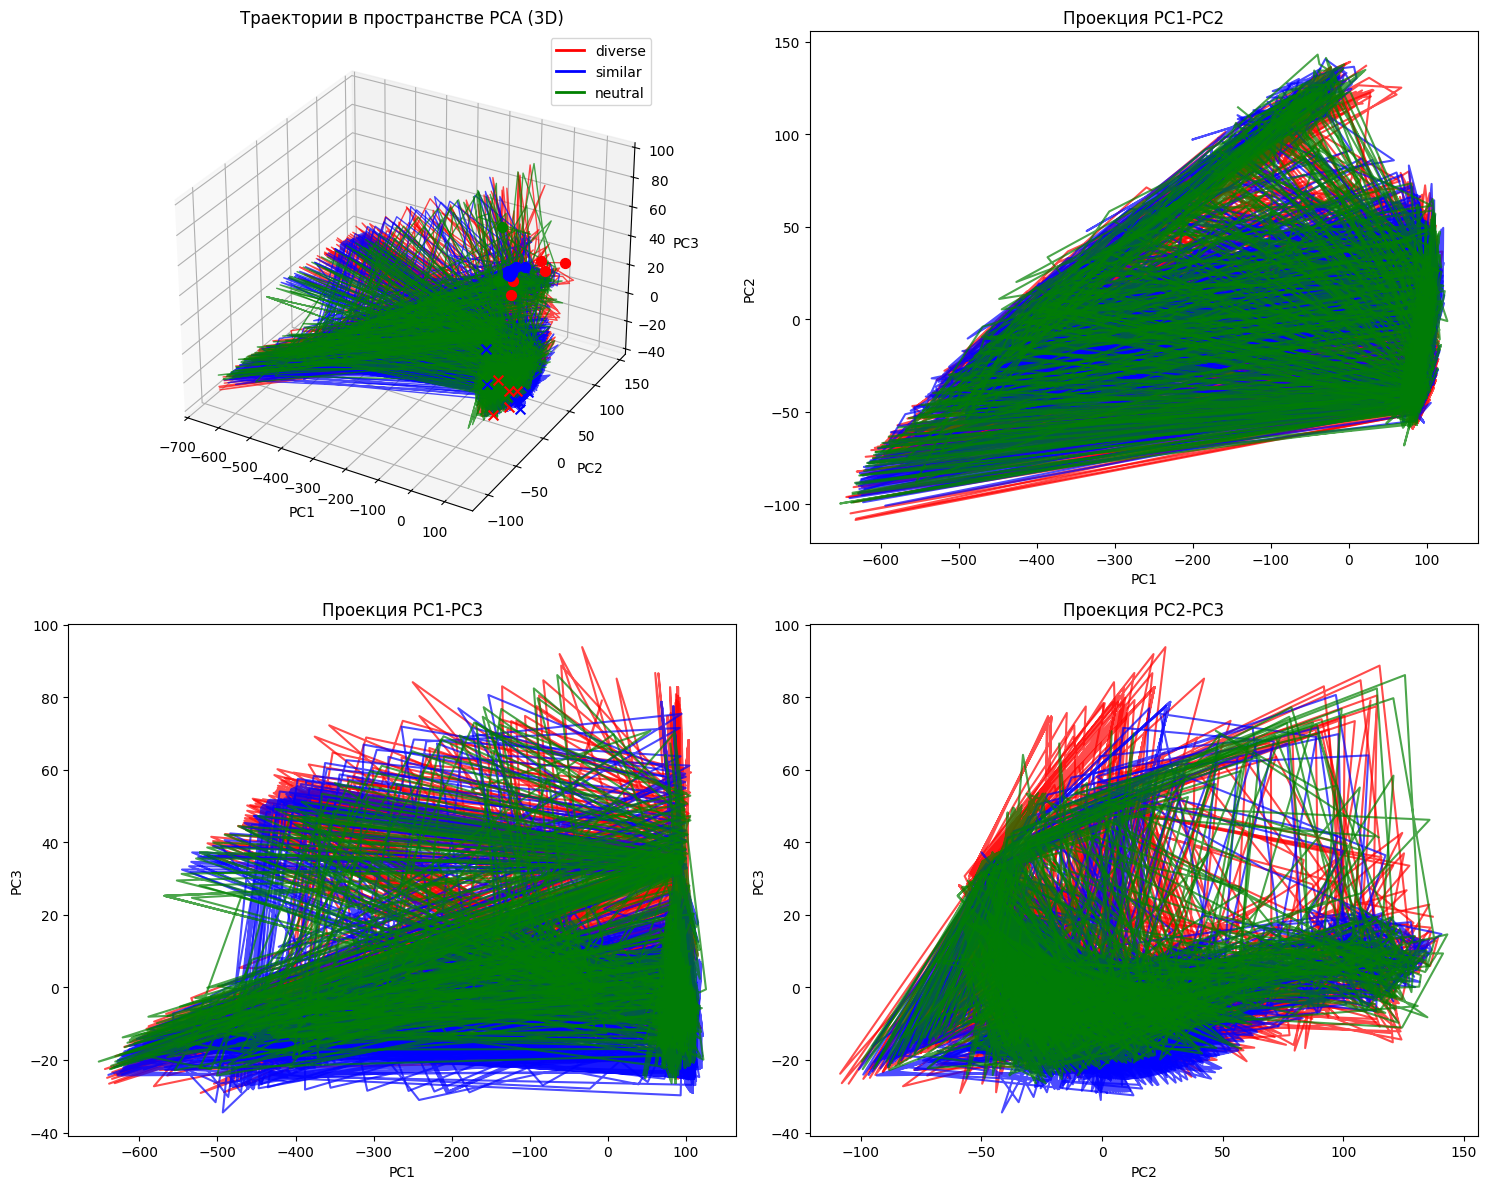

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создание 3D визуализации
fig = plt.figure(figsize=(15, 12))

# 3D график всех траекторий
ax1 = fig.add_subplot(221, projection='3d')

colors = {'diverse': 'red', 'similar': 'blue', 'neutral': 'green'}
start_idx = 0

for group_name, group_trajectories in trajectories.items():
    for i, trajectory in enumerate(group_trajectories):
        end_idx = start_idx + len(trajectory)
        traj_pca = states_pca[start_idx:end_idx]
        
        ax1.plot(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2], 
                color=colors[group_name], alpha=0.7, linewidth=1)
        
        # Отмечаем начальную точку
        ax1.scatter(traj_pca[0, 0], traj_pca[0, 1], traj_pca[0, 2], 
                   color=colors[group_name], s=50, marker='o')
        
        # Отмечаем конечную точку
        ax1.scatter(traj_pca[-1, 0], traj_pca[-1, 1], traj_pca[-1, 2], 
                   color=colors[group_name], s=50, marker='x')
        
        start_idx = end_idx

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('Траектории в пространстве PCA (3D)')

# Легенда
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=group) 
                  for group, color in colors.items()]
ax1.legend(handles=legend_elements)

# 2D проекции
ax2 = fig.add_subplot(222)
start_idx = 0
for group_name, group_trajectories in trajectories.items():
    for i, trajectory in enumerate(group_trajectories):
        end_idx = start_idx + len(trajectory)
        traj_pca = states_pca[start_idx:end_idx]
        ax2.plot(traj_pca[:, 0], traj_pca[:, 1], color=colors[group_name], alpha=0.7)
        start_idx = end_idx
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Проекция PC1-PC2')

ax3 = fig.add_subplot(223)
start_idx = 0
for group_name, group_trajectories in trajectories.items():
    for i, trajectory in enumerate(group_trajectories):
        end_idx = start_idx + len(trajectory)
        traj_pca = states_pca[start_idx:end_idx]
        ax3.plot(traj_pca[:, 0], traj_pca[:, 2], color=colors[group_name], alpha=0.7)
        start_idx = end_idx
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC3')
ax3.set_title('Проекция PC1-PC3')

ax4 = fig.add_subplot(224)
start_idx = 0
for group_name, group_trajectories in trajectories.items():
    for i, trajectory in enumerate(group_trajectories):
        end_idx = start_idx + len(trajectory)
        traj_pca = states_pca[start_idx:end_idx]
        ax4.plot(traj_pca[:, 1], traj_pca[:, 2], color=colors[group_name], alpha=0.7)
        start_idx = end_idx
ax4.set_xlabel('PC2')
ax4.set_ylabel('PC3')
ax4.set_title('Проекция PC2-PC3')

plt.tight_layout()
plt.show()

## Анализ динамики: расстояния между состояниями

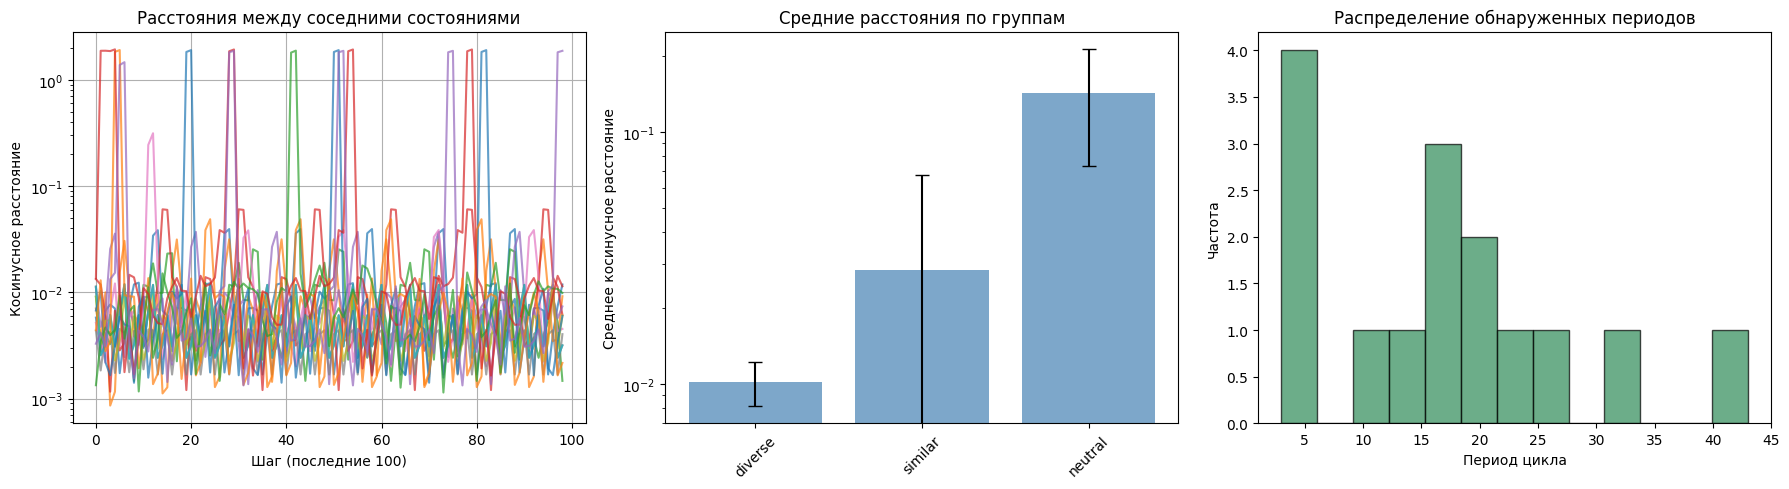

In [47]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Косинусные расстояния между соседними состояниями (последние 100 шагов)
ax = axes[0]
for group_name, results in analysis_results.items():
    for result in results:
        distances = result['fixed_point']['distances']
        ax.plot(distances[-100:], alpha=0.7, label=f"{group_name}_{result['trajectory_index']}")

ax.set_xlabel('Шаг (последние 100)')
ax.set_ylabel('Косинусное расстояние')
ax.set_title('Расстояния между соседними состояниями')
ax.set_yscale('log')
ax.grid(True)
# ax.legend()  # можно раскомментировать, если групп немного

# График 2: Средние расстояния по группам
ax = axes[1]
group_means = {}
group_stds = {}

for group_name, results in analysis_results.items():
    mean_distances = [result['fixed_point']['mean_distance'] for result in results]
    group_means[group_name] = np.mean(mean_distances)
    group_stds[group_name] = np.std(mean_distances)

groups = list(group_means.keys())
means = list(group_means.values())
stds = list(group_stds.values())

ax.bar(groups, means, yerr=stds, capsize=5, alpha=0.7, color='steelblue')
ax.set_ylabel('Среднее косинусное расстояние')
ax.set_title('Средние расстояния по группам')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# График 3: Распределение периодов циклов
ax = axes[2]
all_periods = []
for group_name, results in analysis_results.items():
    for result in results:
        period = result['cycle']['best_period']
        if period is not None and period > 0:
            all_periods.append(period)

if all_periods:
    ax.hist(all_periods, bins=min(20, len(set(all_periods))), alpha=0.7, edgecolor='black', color='seagreen')
    ax.set_xlabel('Период цикла')
    ax.set_ylabel('Частота')
    ax.set_title('Распределение обнаруженных периодов')
else:
    ax.text(0.5, 0.5, 'Циклы\nне обнаружены', 
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Распределение периодов циклов')

plt.tight_layout()
plt.show()

## Сводная таблица результатов

In [48]:
import pandas as pd

# Создание сводной таблицы
summary_data = []

for group_name, results in analysis_results.items():
    for result in results:
        summary_data.append({
            'Группа': group_name,
            'Промпт': result['prompt'][:50] + '...' if len(result['prompt']) > 50 else result['prompt'],
            'Неподвижная точка': result['fixed_point']['is_fixed_point'],
            'Среднее расстояние': f"{result['fixed_point']['mean_distance']:.6f}",
            'Цикл': result['cycle']['is_cycle'],
            'Период цикла': result['cycle']['best_period'],
            'Расстояние цикла': f"{result['cycle']['best_distance']:.6f}"
        })

summary_df = pd.DataFrame(summary_data)
print("Сводная таблица результатов:")
print(summary_df.to_string(index=False))

# Статистика по группам
print("\n" + "="*80)
print("СТАТИСТИКА ПО ГРУППАМ")
print("="*80)

for group_name in all_prompts.keys():
    group_data = summary_df[summary_df['Группа'] == group_name]
    
    fixed_points = group_data['Неподвижная точка'].sum()
    cycles = group_data['Цикл'].sum()
    total = len(group_data)
    
    print(f"\nГруппа '{group_name}' ({total} промптов):")
    print(f"  Неподвижные точки: {fixed_points}/{total} ({fixed_points/total*100:.1f}%)")
    print(f"  Циклы: {cycles}/{total} ({cycles/total*100:.1f}%)")
    print(f"  Неклассифицированные: {total-fixed_points-cycles}/{total} ({(total-fixed_points-cycles)/total*100:.1f}%)")

# Статистика по хаосу
chaotic_pairs = sum(1 for result in chaos_results if result['chaos_analysis']['is_chaotic'])
total_pairs = len(chaos_results)

print(f"\nХаотическое поведение (группа 'similar'):")
print(f"  Хаотичных пар: {chaotic_pairs}/{total_pairs} ({chaotic_pairs/total_pairs*100:.1f}%)")
print(f"  Средний показатель Ляпунова: {np.mean(lyapunov_exponents):.6f}")

Сводная таблица результатов:
 Группа                                                Промпт  Неподвижная точка Среднее расстояние  Цикл  Период цикла Расстояние цикла
diverse         The gravitational constant G is approximately              False           0.010067  True            15         0.000011
diverse        In a binary tree data structure, each node has              False           0.008772  True            11         0.000005
diverse               The French Revolution began in the year              False           0.008527  True            18         0.000039
diverse To bake a simple sponge cake, first preheat the ov...              False           0.014073  True            16         0.000006
diverse            Quantum entanglement is a phenomenon where              False           0.009620  True            17         0.000010
similar                                The cat sat on the mat              False           0.005527  True             6         0.000001
similar     